# Step Timing Analysis

This notebook finds all `timing_and_parameters.txt` files under `external_data/`, parses the regular and ML step statistics, and visualizes them.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
from typing import Optional

def locate_external_data(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        external_data = candidate / 'external_data'
        if external_data.exists():
            return external_data
    raise FileNotFoundError('Could not locate an external_data directory from the current working directory.')


STEP_LINE_RE = re.compile(
    r'^\s*(Regular|ML): count=(\d+), total_ms=([\d.]+), avg_ms=([\d.]+), min_ms=([\d.]+), max_ms=([\d.]+)$',
    re.MULTILINE,
)
SUBSTEP_RE = re.compile(
    r'^\s*([a-zA-Z0-9_]+): count=(\d+), total_s=([\d.]+), avg_s=([\d.]+)$',
    re.MULTILINE,
)
KEY_VALUE_RE = re.compile(r'^([^:\n]+):\s*(.+)$')


def parse_named_block(text: str, header: str) -> dict[str, str]:
    pattern = rf'{re.escape(header)}:\n(.*?)(?:\n\n|\Z)'
    match = re.search(pattern, text, flags=re.DOTALL)
    if not match:
        return {}
    values = {}
    for line in match.group(1).splitlines():
        line = line.strip()
        if not line:
            continue
        kv = KEY_VALUE_RE.match(line)
        if kv:
            values[kv.group(1).strip()] = kv.group(2).strip()
    return values


def maybe_number(value):
    if value is None:
        return None
    if isinstance(value, (int, float)):
        return value
    value = value.strip()
    if value in {'N/A', ''}:
        return None
    try:
        number = float(value)
    except ValueError:
        return value
    return int(number) if number.is_integer() else number


def job_label(job_name: str, params: dict[str, str]) -> str:
    mpi_ranks = maybe_number(params.get('MPI_RANKS'))
    parts = []
    if mpi_ranks is not None:
        parts.append(f'{mpi_ranks}r')
    lowered = job_name.lower()
    if 'gpu' in lowered:
        gpu_match = re.search(r'_(\d+)gpu', lowered)
        parts.append(f"{gpu_match.group(1)} GPU" if gpu_match else 'GPU')
    elif 'cpu' in lowered:
        cpu_match = re.search(r'_(\d+)cpu', lowered)
        parts.append(f"{cpu_match.group(1)} CPU" if cpu_match else 'CPU')
    else:
        parts.append(job_name)
    return ' | '.join(str(part) for part in parts)


def parse_timing_file(path: Path) -> dict:
    text = path.read_text()
    top_level = {}
    for line in text.splitlines():
        if line.strip() in {'Parameters:', 'Solver step statistics (parsed from solver log):', 'Timings (seconds):'}:
            break
        kv = KEY_VALUE_RE.match(line)
        if kv:
            top_level[kv.group(1).strip()] = kv.group(2).strip()

    params = parse_named_block(text, 'Parameters')
    timings = parse_named_block(text, 'Timings (seconds)')

    record = {
        'path': str(path),
        'run_dir': path.parent.name,
        'job_name': top_level.get('Job Name', path.parent.name),
        'slurm_job_id': maybe_number(top_level.get('Slurm Job ID')),
    }

    for key, value in params.items():
        record[f'param_{key.lower()}'] = maybe_number(value)
    for key, value in timings.items():
        clean_key = key.lower().replace(':', '').replace(' ', '_')
        record[f'timing_{clean_key}_s'] = maybe_number(value)

    parsed_step_lines = re.search(r'Parsed step lines:\s*(\d+)', text)
    record['parsed_step_lines'] = maybe_number(parsed_step_lines.group(1)) if parsed_step_lines else None

    for match in STEP_LINE_RE.finditer(text):
        step_kind = match.group(1).lower()
        record[f'{step_kind}_count'] = int(match.group(2))
        record[f'{step_kind}_total_ms'] = float(match.group(3))
        record[f'{step_kind}_avg_ms'] = float(match.group(4))
        record[f'{step_kind}_min_ms'] = float(match.group(5))
        record[f'{step_kind}_max_ms'] = float(match.group(6))

    for match in SUBSTEP_RE.finditer(text):
        name = match.group(1).lower()
        record[f'ml_substep_{name}_count'] = int(match.group(2))
        record[f'ml_substep_{name}_total_s'] = float(match.group(3))
        record[f'ml_substep_{name}_avg_s'] = float(match.group(4))

    record['label'] = job_label(record['job_name'], params)
    return record


external_data = locate_external_data()
timing_files = sorted(external_data.glob('**/timing_and_parameters.txt'))
timing_files = list(filter(lambda p: ('circle_r500_d100_s1000' in str(p)), timing_files))
print(f'Found {len(timing_files)} timing files under {external_data}')
timing_files[:5]

Found 8 timing files under /rwthfs/rz/cluster/hpcwork/ro092286/smartsim/mini_app/external_data


[PosixPath('/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/mini_app/external_data/circle_r500_d100_s1000_triangular_2160x1080_c23mm_1n_1t_c__rank0_gather_none_1gpu_perfect_model/timing_and_parameters.txt'),
 PosixPath('/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/mini_app/external_data/circle_r500_d100_s1000_triangular_2160x1080_c23mm_1n_1t_c__rank0_gather_none_1gpu_perfect_model_revamped_prepare/timing_and_parameters.txt'),
 PosixPath('/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/mini_app/external_data/circle_r500_d100_s1000_triangular_2160x1080_c23mm_1n_1t_c__rank0_gather_none_24cpu_perfect_model/timing_and_parameters.txt'),
 PosixPath('/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/mini_app/external_data/circle_r500_d100_s1000_triangular_2160x1080_c23mm_1n_1t_c__rank0_gather_none_24cpu_perfect_model_inter/timing_and_parameters.txt'),
 PosixPath('/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/mini_app/external_data/circle_r500_d100_s1000_triangular_2160x1080_c23mm_1n_1t_c__rank0_gather_non

In [3]:
records = [parse_timing_file(path) for path in timing_files]
df = pd.DataFrame(records).sort_values(['param_mpi_ranks', 'job_name'], na_position='last').reset_index(drop=True)
valid_df = df.dropna(subset=['regular_avg_ms', 'ml_avg_ms']).copy()

summary_columns = [
    'label',
    'job_name',
    'slurm_job_id',
    'param_mpi_ranks',
    'regular_avg_ms',
    'ml_avg_ms',
    'ml_substep_prepare_data_avg_s',
    'ml_substep_put_tensor_avg_s',
    'ml_substep_run_model_avg_s',
    'ml_substep_unpack_avg_s',
    'ml_substep_ml_cleanup_avg_s',
    'ml_substep_ml_total_wall_avg_s',
]

print(f'Parsed regular/ML step timings for {len(valid_df)} of {len(df)} runs.')
display(valid_df[[col for col in summary_columns if col in valid_df.columns]].head(20))
valid_df


Parsed regular/ML step timings for 8 of 8 runs.


,label,job_name,slurm_job_id,param_mpi_ranks,regular_avg_ms,ml_avg_ms,ml_substep_prepare_data_avg_s,ml_substep_put_tensor_avg_s,ml_substep_run_model_avg_s,ml_substep_unpack_avg_s,ml_substep_ml_cleanup_avg_s,ml_substep_ml_total_wall_avg_s
0,1r | 1 GPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66153670,1,469.260,953.781,0.466045,0.214563,0.034242,0.025389,0.211979,0.952389
1,1r | 1 GPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66166058,1,520.031,209.602,0.000002,0.152986,0.025340,0.030343,0.000000,0.208856
2,1r | 24 CPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66155862,1,465.100,900.418,0.462826,0.166135,0.043362,0.024061,0.203084,0.899626
3,1r | 24 CPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66157081,1,509.241,1044.203,0.475308,0.165626,0.168594,0.026387,0.207278,1.043375
4,1r | 24 CPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66156829,1,465.681,966.978,0.460370,0.180379,0.098450,0.024121,0.202243,0.965725
5,1r | 24 CPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66157612,1,520.866,230.962,0.000002,0.155506,0.044246,0.030425,0.000000,0.230350
6,1r | 2 GPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66153673,1,465.442,910.778,0.457934,0.199782,0.027040,0.024361,0.200345,0.909617
7,1r | 4 GPU,circle_r500_d100_s1000_triangular_2160x1080_c2...,66153675,1,535.941,1007.229,0.514454,0.210503,0.025742,0.028780,0.226603,1.006320


,path,run_dir,job_name,slurm_job_id,param_init_mode,param_radius,param_init_depth,param_total_steps,param_save_every,param_save_mode,param_triangular_scale,param_target_width,param_target_height,param_chunk_size,param_mpi_ranks,param_io_mode,param_mpi_sync_mode,param_rank_grid_x,param_rank_grid_z,param_overwrite_output,param_skip_rendering,param_skip_compile,param_ffmpeg_threads,param_render_cpus,param_reduced_height,param_height_min,param_solver_step_log,timing_preparation_s,timing_compilation_s,timing_solving_s,timing_top_view_rendering_s,timing_slice_full_height_rendering_s,timing_slice_reduced_height_rendering_s,timing_top_view_video_s,timing_slice_full_height_video_s,timing_combined_video_1_s,timing_combined_video_16_s,timing_total_s,parsed_step_lines,regular_count,regular_total_ms,regular_avg_ms,regular_min_ms,regular_max_ms,ml_count,ml_total_ms,ml_avg_ms,ml_min_ms,ml_max_ms,ml_substep_prepare_data_count,ml_substep_prepare_data_total_s,ml_substep_prepare_data_avg_s,ml_substep_put_tensor_count,ml_substep_put_tensor_total_s,ml_substep_put_tensor_avg_s,ml_substep_run_model_count,ml_substep_run_model_total_s,ml_substep_run_model_avg_s,ml_substep_unpack_count,ml_substep_unpack_total_s,ml_substep_unpack_avg_s,ml_substep_ml_total_wall_count,ml_substep_ml_total_wall_total_s,ml_substep_ml_total_wall_avg_s,ml_substep_ml_accounted_count,ml_substep_ml_accounted_total_s,ml_substep_ml_accounted_avg_s,ml_substep_ml_cleanup_count,ml_substep_ml_cleanup_total_s,ml_substep_ml_cleanup_avg_s,label
0,/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/m...,circle_r500_d100_s1000_triangular_2160x1080_c2...,circle_r500_d100_s1000_triangular_2160x1080_c2...,66153670,circle,500,100,1000,1,triangular,1,2160,1080,60,1,rank0_gather,none,0,0,1,0,0,16,24,135,40,logs/mini_app_output_66153670.txt,11,6,783,3,1,0,6,4,1: 5,9: 4,823,1000,500,234629.803,469.260,435.818,517.868,500,476890.490,953.781,900.694,3685.62,500,233.022256,0.466045,500,107.281554,0.214563,500,17.120833,0.034242,500,12.694659,0.025389,500,476.194654,0.952389,500,476.108922,0.952218,500,105.989624,0.211979,1r | 1 GPU
1,/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/m...,circle_r500_d100_s1000_triangular_2160x1080_c2...,circle_r500_d100_s1000_triangular_2160x1080_c2...,66166058,circle,500,100,1000,1,triangular,1,2160,1080,60,1,rank0_gather,none,0,0,1,0,0,16,24,135,40,logs/mini_app_output_66166058.txt,10,8,451,3,1,0,7,4,1: 4,9: 5,493,1000,500,260015.376,520.031,483.382,579.987,500,104800.996,209.602,200.396,2749.48,500,0.001082,0.000002,500,76.493080,0.152986,500,12.669787,0.025340,500,15.171568,0.030343,500,104.428138,0.208856,500,104.335516,0.208671,500,0.000000,0.000000,1r | 1 GPU
2,/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/m...,circle_r500_d100_s1000_triangular_2160x1080_c2...,circle_r500_d100_s1000_triangular_2160x1080_c2...,66155862,circle,500,100,1000,1,triangular,1,2160,1080,60,1,rank0_gather,none,0,0,1,0,0,16,24,135,40,logs/mini_app_output_66155862.txt,10,6,726,2,1,0,6,3,1: 4,9: 4,762,1000,500,232549.816,465.100,435.470,492.272,500,450209.222,900.418,873.317,2342.80,500,231.413125,0.462826,500,83.067362,0.166135,500,21.680987,0.043362,500,12.030480,0.024061,500,449.813015,0.899626,500,449.733918,0.899468,500,101.541969,0.203084,1r | 24 CPU
3,/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/m...,circle_r500_d100_s1000_triangular_2160x1080_c2...,circle_r500_d100_s1000_triangular_2160x1080_c2...,66157081,circle,500,100,1000,1,triangular,1,2160,1080,60,1,rank0_gather,none,0,0,1,0,0,16,24,135,40,logs/mini_app_output_66157081.txt,6,6,811,3,1,0,7,4,1: 4,9: 5,847,1000,500,254620.682,509.241,473.753,579.636,500,522101.270,1044.203,1016.400,2541.97,500,237.653783,0.475308,500,82.812978,0.165626,500,84.297243,0.168594,500,13.193740,0.026387,500,521.687370,1.043375,500,521.597020,1.043194,500,103.639215,0.207278,1r | 24 CPU
4,/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/m...,circle_r500_d100_s1000_triangular_2160x1080_c2...,circle_r500_d100_s1000_triangular_2160x1080_c2...,66156829,circle,500,100,1000

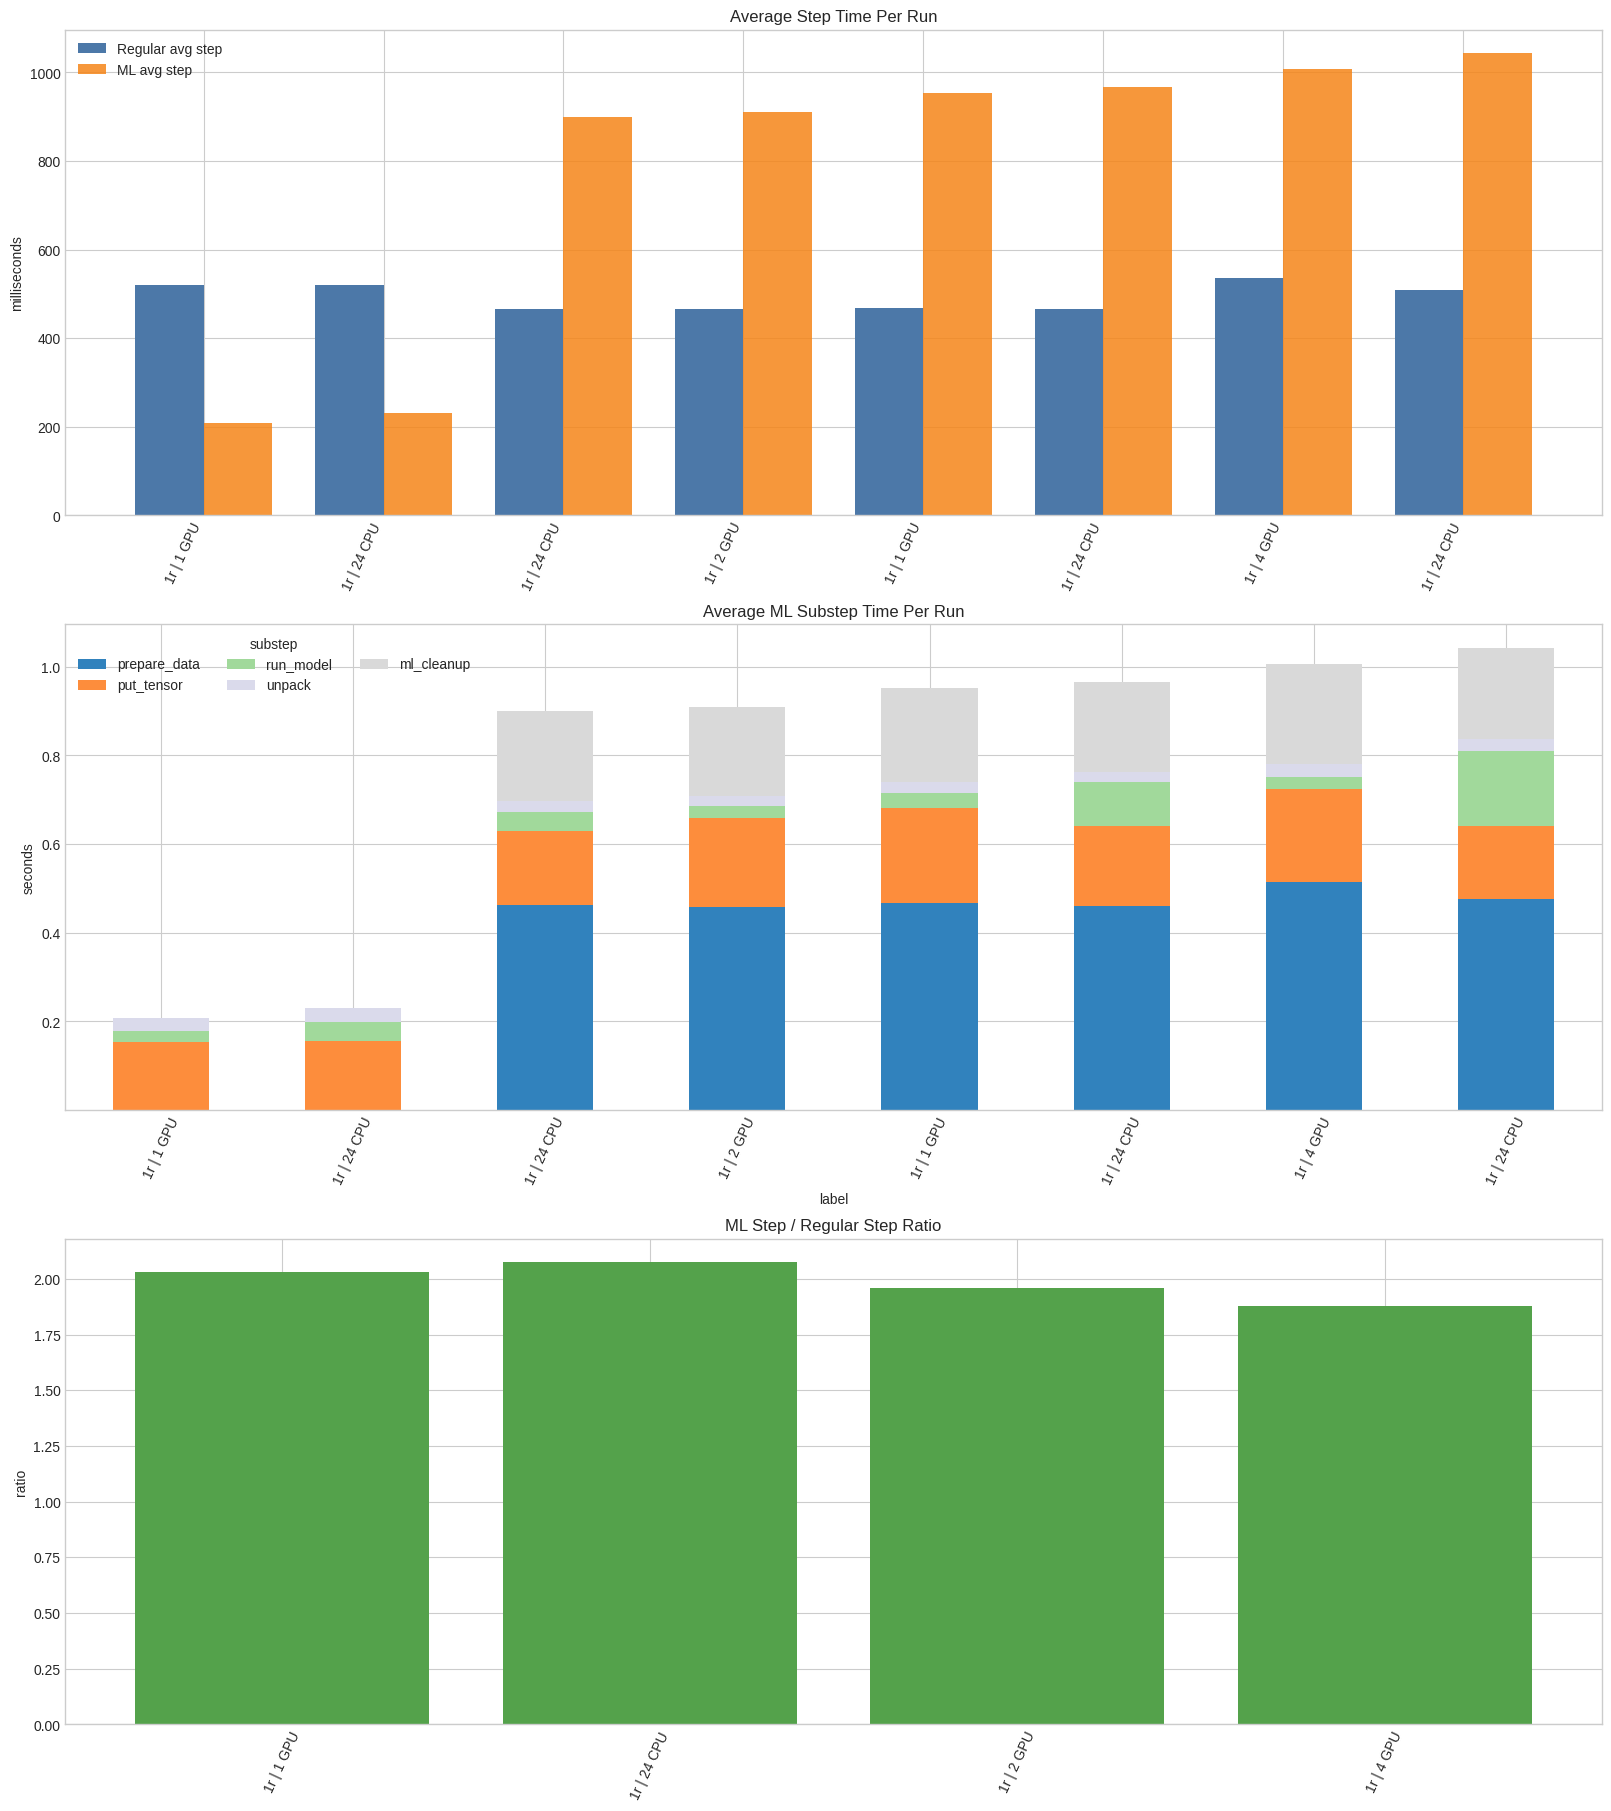

In [4]:
plot_df = valid_df.sort_values('ml_avg_ms').reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 18), constrained_layout=True)

x = list(range(len(plot_df)))
bar_width = 0.38
axes[0].bar([i - bar_width / 2 for i in x], plot_df['regular_avg_ms'], width=bar_width, label='Regular avg step', color='#4C78A8')
axes[0].bar([i + bar_width / 2 for i in x], plot_df['ml_avg_ms'], width=bar_width, label='ML avg step', color='#F58518', alpha=0.85)
axes[0].set_title('Average Step Time Per Run')
axes[0].set_ylabel('milliseconds')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df['label'], rotation=65, ha='right')
axes[0].legend()

substep_avg_columns = [
    'ml_substep_prepare_data_avg_s',
    'ml_substep_put_tensor_avg_s',
    'ml_substep_run_model_avg_s',
    'ml_substep_unpack_avg_s',
    'ml_substep_ml_cleanup_avg_s',
]
available_substep_avg_columns = [col for col in substep_avg_columns if col in plot_df.columns]
substep_avg_df = plot_df[['label', *available_substep_avg_columns]].set_index('label').fillna(0.0)
substep_avg_df.columns = [col.replace('ml_substep_', '').replace('_avg_s', '') for col in substep_avg_df.columns]
substep_avg_df.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20c')
axes[1].set_title('Average ML Substep Time Per Run')
axes[1].set_ylabel('seconds')
axes[1].tick_params(axis='x', rotation=65)
axes[1].legend(title='substep', ncols=3)

ratio_df = plot_df[['label', 'regular_avg_ms', 'ml_avg_ms']].copy()
ratio_df['ml_vs_regular_ratio'] = ratio_df['ml_avg_ms'] / ratio_df['regular_avg_ms']
axes[2].bar(ratio_df['label'], ratio_df['ml_vs_regular_ratio'], color='#54A24B')
axes[2].set_title('ML Step / Regular Step Ratio')
axes[2].set_ylabel('ratio')
axes[2].tick_params(axis='x', rotation=65)

plt.show()
